In [1]:
!pip install openai==0.28

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 7.0 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 1.106.0
    Uninstalling openai-1.106.0:
      Successfully uninstalled openai-1.106.0


In [2]:
import pandas as pd
import os
import numpy as np
from sentence_transformers import SentenceTransformer
import nltk
import zipfile
import os
from bs4 import BeautifulSoup
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from google.colab import files
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [5]:
from google.colab import files
uploaded = files.upload()

Saving UpdatedResumeDataSet Optimizing Curriculum Vitae Concordance.csv to UpdatedResumeDataSet Optimizing Curriculum Vitae Concordance.csv


In [6]:
df = pd.read_csv('UpdatedResumeDataSet Optimizing Curriculum Vitae Concordance.csv')

In [ ]:
df

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...
957,Testing,Computer Skills: â¢ Proficient in MS office (...
958,Testing,â Willingness to accept the challenges. â ...
959,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [7]:
df.shape[0]

962

In [8]:
!pip install --upgrade scipy

In [9]:
# Download necessary NLTK resources (only need to run once)
nltk.download('punkt_tab')
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [10]:
def preprocess_text(text):
    """
    Preprocesses a given text string for NLP tasks. This includes cleaning the text,
    tokenizing, removing stopwords, and lemmatizing the words.

    Args:
    text (str): The text string to preprocess.

    Returns:
    str: The preprocessed text.
    """
    if not isinstance(text, str):  # Safeguard against non-string input like NaN
        return ""

     # 1. Add spaces around tags, then remove them
    text = re.sub(r'<[^>]+>', ' ', text)

    # 2. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # 3. Remove emails
    text = re.sub(r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b', '', text)

    # 4. Remove special characters (keep only words and whitespace)
    text = re.sub(r'[^\w\s]', '', text)

    #5 Trip out all non-ASCII characters like â, €, ™, etc., that appear due to encoding mismatches
    text = text.encode('ascii', 'ignore').decode()

    text = text.lower()

    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word not in stop_words]

    lemmatizer = WordNetLemmatizer()
    lemmatized_text = [lemmatizer.lemmatize(word) for word in filtered_tokens]

    return ' '.join(lemmatized_text)

In [11]:
# Apply preprocessing
# Keep original resume text in a new column
df['Resume_original'] = df['Resume']

# Apply preprocessing only on 'Resume'
df['Resume'] = df['Resume'].apply(preprocess_text)


In [12]:
df

,Category,Resume,Resume_original
0,Data Science,skill programming language python panda numpy ...,Skills * Programming Languages: Python (pandas...
1,Data Science,education detail may 2013 may 2017 uitrgpv dat...,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,area interest deep learning control system des...,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,skill r python sap hana tableau sap hana sql s...,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,education detail mca ymcaust faridabad haryana...,"Education Details \r\n MCA YMCAUST, Faridab..."
...,...,...,...
957,Testing,computer skill proficient m office word basic ...,Computer Skills: â¢ Proficient in MS office (...
958,Testing,willingness accept challenge positive thinking...,â Willingness to accept the challenges. â ...
959,Testing,personal skill quick learner eagerness learn n...,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
960,Testing,computer skill software knowledge mspower poin...,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...


In [13]:
def drop_duplicates(df, column_name):
    """
    Drops duplicates based on a specified column from the DataFrame.

    Args:
    df (pd.DataFrame): The DataFrame from which to remove duplicates.
    column_name (str): The name of the column based on which duplicates will be identified.

    Returns:
    pd.DataFrame: DataFrame with duplicates removed based on the specified column.
    """
    if column_name not in df.columns:
        raise ValueError(f"Column '{column_name}' not found in DataFrame")

    original_size = df.shape[0]
    df_cleaned = df.drop_duplicates(subset=[column_name])
    new_size = df_cleaned.shape[0]

    print(f"Dropped {original_size - new_size} duplicates from '{column_name}'. New dataset size: {new_size}")

    return df_cleaned

In [14]:
df = drop_duplicates(df, column_name='Resume')

Dropped 796 duplicates from 'Resume'. New dataset size: 166


In [15]:
#resume_df_final = df[['Resume']].rename(columns={'Resume': 'resume_summary'})
#resume_df_final = df[['Resume', 'Resume_original']].rename(columns={'Resume': 'resume_summary'})
#resume_df_final = df[['Resume', 'Resume_original', 'Category']].rename(columns={'Resume': 'resume_summary'})
resume_df_final = df[['Resume', 'Resume_original', 'Category']].rename(columns={'Resume': 'resume_summary','Category': 'Category_original'})
jobs_df_final = df[['Category']].rename(columns={'Category': 'job_summary'})

In [16]:
resume_df_final

,resume_summary,Resume_original,Category_original
0,skill programming language python panda numpy ...,Skills * Programming Languages: Python (pandas...,Data Science
1,education detail may 2013 may 2017 uitrgpv dat...,Education Details \r\nMay 2013 to May 2017 B.E...,Data Science
2,area interest deep learning control system des...,"Areas of Interest Deep Learning, Control Syste...",Data Science
3,skill r python sap hana tableau sap hana sql s...,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,Data Science
4,education detail mca ymcaust faridabad haryana...,"Education Details \r\n MCA YMCAUST, Faridab...",Data Science
...,...,...,...
894,computer skill proficient m office word basic ...,Computer Skills: â¢ Proficient in MS office (...,Testing
895,willingness accept challenge positive thinking...,â Willingness to accept the challenges. â ...,Testing
896,personal skill quick learner eagerness learn n...,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne...",Testing
897,computer skill software knowledge mspower poin...,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...,Testing


In [17]:
jobs_df_final

,job_summary
0,Data Science
1,Data Science
2,Data Science
3,Data Science
4,Data Science
...,...
894,Testing
895,Testing
896,Testing
897,Testing


In [18]:
# Import the packages and set some parameters

from tqdm.notebook import tqdm
import json
import pandas as pd
import os
import requests
import numpy as np
import time
import pickle

In [19]:
import openai

# Set parameters for Azure openai
openai_rg_name = 'openai-lab'
openai_svc_name = 'openai-lab-rm'
openai.api_type = "azure"
openai.api_version = "2023-03-15-preview"

# The openai endpoint and key that you acquire when setting up Azure openai.
openai.api_base = "https://openaialexandra.openai.azure.com/"
#openai.api_key = os.getenv("OPENAI_API_KEY")
openai.api_key = "1UCwRNRoRgKrOpzvgzFObYi20I3mkwnud6GbidjreE1F54vF28AVJQQJ99BHACfhMk5XJ3w3AAABACOG0CsP"
#openai.api_key = os.getenv("job_resume_key")

# Define the model for summarizing CV documents. The model deployed here is a GPT-3.5-turbo.
text_summarization_model = "gpt-35-turbo"
embedding_model = "text-embedding-ada-002"         # deployed name in Azure

In [20]:
def get_embedding(text, deployment_id=embedding_model):
    result = openai.Embedding.create(
        deployment_id=deployment_id,
        input=text
    )
    return np.array(result["data"][0]["embedding"])


In [21]:
def encode_column(df, column, batch_size=16, encoded_column_suffix="_encoded"):
    vectors = []
    for start in tqdm(range(0, len(df), batch_size), desc=f"Embedding {column}"):
        batch_texts = df[column].iloc[start:start+batch_size].tolist()
        batch_embeddings = [
            get_embedding(text, embedding_model) for text in batch_texts
        ]
        vectors.extend(batch_embeddings)
    df[column + encoded_column_suffix] = vectors
    return df


In [22]:
# Split Function
# -------------------
def split_df(df, train_frac=0.8, val_frac=0.1, random_state=42):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    n = len(df_shuffled)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return (
        df_shuffled.iloc[:train_end].reset_index(drop=True),
        df_shuffled.iloc[train_end:val_end].reset_index(drop=True),
        df_shuffled.iloc[val_end:].reset_index(drop=True),
    )


In [23]:
# Evaluation Run
# -------------------
def perform_evaluation_run(resume_df, jobs_df, random_seed=42, similarity_threshold=0.7):
    # Split into train/val/test
    resume_train, resume_val, resume_test = split_df(resume_df, random_state=random_seed)
    jobs_train, jobs_val, jobs_test = split_df(jobs_df, random_state=random_seed)

    # Encode only test sets
    resume_test = encode_column(resume_test, "resume_summary")
    jobs_test = encode_column(jobs_test, "job_summary")

    # Convert to numpy
    resume_test_embeds = np.vstack(resume_test["resume_summary_encoded"].values)
    jobs_test_embeds = np.vstack(jobs_test["job_summary_encoded"].values)

    # Compute similarity matrix
    similarity_matrix = cosine_similarity(resume_test_embeds, jobs_test_embeds)

    # Collect matches
    results = []
    for r_idx in range(similarity_matrix.shape[0]):
        for j_idx in range(similarity_matrix.shape[1]):
            score = similarity_matrix[r_idx, j_idx]
            results.append({
                "resume_index": r_idx,
                "job_index": j_idx,
                "similarity_score": score,
                "resume_summary": resume_test.iloc[r_idx]["resume_summary"],
                "resume_original": resume_test.iloc[r_idx]["Resume_original"],
                "category_original": resume_test.iloc[r_idx]["Category_original"],
                #"job_summary": jobs_test.iloc[j_idx]["job_summary"],
                "predicted_job_category": jobs_test.iloc[j_idx]["job_summary"],
                "is_correct": score >= similarity_threshold
            })

    matches_df = pd.DataFrame(results)

    # Metrics
    metrics = {
        "avg_similarity": matches_df["similarity_score"].mean(),
        "median_similarity": matches_df["similarity_score"].median(),
        "std_similarity": matches_df["similarity_score"].std(),
        "accuracy": matches_df["is_correct"].mean(),
        "num_matches": len(matches_df),
        "num_correct_matches": matches_df["is_correct"].sum(),
        "pct_correct_matches": matches_df["is_correct"].mean() * 100,
    }

    return metrics, matches_df

In [24]:
# -------------------
# Embedding Functions
# -------------------
def get_embedding(text, deployment_id=embedding_model):
    result = openai.Embedding.create(
        deployment_id=deployment_id,
        input=text
    )
    return np.array(result["data"][0]["embedding"])


In [25]:
def encode_column(df, column, batch_size=16, encoded_column_suffix="_encoded"):
    vectors = []
    for start in tqdm(range(0, len(df), batch_size), desc=f"Embedding {column}"):
        batch_texts = df[column].iloc[start:start+batch_size].tolist()
        batch_embeddings = [get_embedding(text, embedding_model) for text in batch_texts]
        vectors.extend(batch_embeddings)
    df[column + encoded_column_suffix] = vectors
    return df

In [26]:
# -------------------
# Data Splitting
# -------------------
def split_df(df, train_frac=0.8, val_frac=0.1, random_state=42):
    df_shuffled = df.sample(frac=1, random_state=random_state).reset_index(drop=True)
    n = len(df_shuffled)
    train_end = int(n * train_frac)
    val_end = int(n * (train_frac + val_frac))
    return (
        df_shuffled.iloc[:train_end].reset_index(drop=True),
        df_shuffled.iloc[train_end:val_end].reset_index(drop=True),
        df_shuffled.iloc[val_end:].reset_index(drop=True),
    )


In [27]:
# -------------------
# Single Evaluation Run
# -------------------
'''def perform_evaluation_run(resume_df, jobs_df, random_seed=42, similarity_threshold=0.7):
    resume_train, resume_val, resume_test = split_df(resume_df, random_state=random_seed)
    jobs_train, jobs_val, jobs_test = split_df(jobs_df, random_state=random_seed)

    # Encode only test sets
    resume_test = encode_column(resume_test, "resume_summary")
    jobs_test = encode_column(jobs_test, "job_summary")

    resume_test_embeds = np.vstack(resume_test["resume_summary_encoded"].values)
    jobs_test_embeds = np.vstack(jobs_test["job_summary_encoded"].values)

    similarity_matrix = cosine_similarity(resume_test_embeds, jobs_test_embeds)

    results = []
    for r_idx in range(similarity_matrix.shape[0]):
        for j_idx in range(similarity_matrix.shape[1]):
            score = similarity_matrix[r_idx, j_idx]
            results.append({
                "resume_index": r_idx,
                "job_index": j_idx,
                "similarity_score": score,
                "resume_summary": resume_test.iloc[r_idx]["resume_summary"],
                "resume_original": resume_test.iloc[r_idx]["Resume_original"],
                "category_original": resume_test.iloc[r_idx]["Category_original"],
                #"job_summary": jobs_test.iloc[j_idx]["job_summary"],
                "predicted_job_category": jobs_test.iloc[j_idx]["job_summary"],
                "is_correct": score >= similarity_threshold
            })

    matches_df = pd.DataFrame(results)

    metrics = {
        "avg_similarity": matches_df["similarity_score"].mean(),
        "median_similarity": matches_df["similarity_score"].median(),
        "std_similarity": matches_df["similarity_score"].std(),
        "accuracy": matches_df["is_correct"].mean(),
        "num_matches": len(matches_df),
        "num_correct_matches": matches_df["is_correct"].sum(),
        "pct_correct_matches": matches_df["is_correct"].mean() * 100,
    }

    return metrics, matches_df'''


In [43]:
def perform_evaluation_run(resume_df, jobs_df, random_seed=42, similarity_threshold=0.7):
    # -------------------
    # Data Splitting
    # -------------------
    resume_train, resume_val, resume_test = split_df(resume_df, random_state=random_seed)
    jobs_train, jobs_val, jobs_test = split_df(jobs_df, random_state=random_seed)

    # -------------------
    # Encode only test sets
    # -------------------
    resume_test = encode_column(resume_test, "resume_summary")
    jobs_test = encode_column(jobs_test, "job_summary")

    # Convert to numpy
    resume_test_embeds = np.vstack(resume_test["resume_summary_encoded"].values)
    jobs_test_embeds = np.vstack(jobs_test["job_summary_encoded"].values)

    # -------------------
    # Compute similarity matrix
    # -------------------
    similarity_matrix = cosine_similarity(resume_test_embeds, jobs_test_embeds)

    # Collect matches
    results = []
    for r_idx in range(similarity_matrix.shape[0]):
        for j_idx in range(similarity_matrix.shape[1]):
            score = similarity_matrix[r_idx, j_idx]
            results.append({
                "resume_index": r_idx,
                "job_index": j_idx,
                "similarity_score": score,
                "resume_summary": resume_test.iloc[r_idx]["resume_summary"],
                "resume_original": resume_test.iloc[r_idx]["Resume_original"],
                "category_original": resume_test.iloc[r_idx]["Category_original"],
                "predicted_job_category": jobs_test.iloc[j_idx]["job_summary"],
                "is_correct_initial": score >= similarity_threshold  # keep raw flag
            })

    matches_df = pd.DataFrame(results)

    # -------------------
    # Adjust threshold dynamically
    # -------------------
    wrong_preds = matches_df[matches_df['category_original'] != matches_df['predicted_job_category']]
    if not wrong_preds.empty:
        adjusted_threshold = wrong_preds['similarity_score'].max()
    else:
        adjusted_threshold = similarity_threshold  # fallback if no wrong predictions

    # Recompute correctness with adjusted threshold
    matches_df['is_correct_adjusted'] = matches_df['similarity_score'] >= adjusted_threshold

    # -------------------
    # Metrics
    # -------------------
    metrics = {
        "avg_similarity": matches_df["similarity_score"].mean(),
        "median_similarity": matches_df["similarity_score"].median(),
        "std_similarity": matches_df["similarity_score"].std(),
        "accuracy": matches_df["is_correct_adjusted"].mean(),
        "num_matches": len(matches_df),
        "num_correct_matches": matches_df["is_correct_adjusted"].sum(),
        "pct_correct_matches": matches_df["is_correct_adjusted"].mean() * 100,
        "adjusted_threshold": adjusted_threshold,
    }

    return metrics, matches_df

In [28]:
# -------------------
# Multi-Run Evaluation
# -------------------
'''def run_multiple_evaluations(resume_df, jobs_df, num_runs=5, similarity_threshold=0.7):
    all_metrics = []
    all_matches_dfs = []

    for run in tqdm(range(num_runs), desc="Running Evaluations"):
        random_seed = 42 + run
        metrics, matches_df = perform_evaluation_run(
            resume_df, jobs_df, random_seed, similarity_threshold
        )
        metrics["run"] = run + 1
        matches_df["run"] = run + 1

        all_metrics.append(metrics)
        all_matches_dfs.append(matches_df)

    metrics_df = pd.DataFrame(all_metrics)
    combined_df = pd.concat(all_matches_dfs)

    # ---- Summary ----
    print("\n=== EVALUATION SUMMARY ===")
    print(f"Average similarity: {metrics_df['avg_similarity'].mean():.3f} ± {metrics_df['avg_similarity'].std():.3f}")
    print(f"Median similarity: {metrics_df['median_similarity'].mean():.3f}")
    print(f"Standard deviation: {metrics_df['std_similarity'].mean():.3f}")
    print(f"Average accuracy: {metrics_df['accuracy'].mean():.3f} ± {metrics_df['accuracy'].std():.3f}")
    print(f"Average number of matches: {metrics_df['num_matches'].mean():.1f}")
    print(f"Average number of correct matches: {metrics_df['num_correct_matches'].mean():.1f}")
    print(f"Average percentage of correct matches: {metrics_df['pct_correct_matches'].mean():.2f}%")

    # ---- Plots ----
    plt.figure(figsize=(15, 10))

    # Similarity across runs
    plt.subplot(2, 2, 1)
    plt.bar(metrics_df["run"], metrics_df["avg_similarity"])
    plt.axhline(y=metrics_df["avg_similarity"].mean(), color="r", linestyle="-")
    plt.xlabel("Run Number")
    plt.ylabel("Average Similarity Score")
    plt.title("Similarity Scores Across Runs")
    plt.grid(True, alpha=0.3)

    # Similarity distribution
    plt.subplot(2, 2, 2)
    sns.histplot(combined_df["similarity_score"], bins=30, kde=True)
    plt.axvline(x=similarity_threshold, color="r", linestyle="--", label=f"Threshold: {similarity_threshold}")
    plt.axvline(x=metrics_df["avg_similarity"].mean(), color="g", linestyle="-", label=f"Mean: {metrics_df['avg_similarity'].mean():.3f}")
    plt.xlabel("Similarity Score")
    plt.ylabel("Frequency")
    plt.title("Distribution of All Similarity Scores")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Heatmap (sample)
    plt.subplot(2, 2, 3)
    sample_size = min(30, len(resume_df))
    pivot_df = combined_df[combined_df["run"] == 1].iloc[:sample_size*sample_size]
    pivot_matrix = pivot_df.pivot_table(
        index="resume_index",
        columns="job_index",
        values="similarity_score",
        aggfunc="mean"
    ).iloc[:sample_size, :sample_size]
    sns.heatmap(pivot_matrix, cmap="viridis", vmin=0, vmax=1)
    plt.title(f"Similarity Heatmap (Sample of {sample_size}x{sample_size})")
    plt.xlabel("Job Index")
    plt.ylabel("Resume Index")

    # Accuracy across runs
    plt.subplot(2, 2, 4)
    plt.bar(metrics_df["run"], metrics_df["pct_correct_matches"])
    plt.axhline(y=metrics_df["pct_correct_matches"].mean(), color="r", linestyle="-")
    plt.xlabel("Run Number")
    plt.ylabel("Percentage of Correct Matches")
    plt.title("Accuracy Across Runs")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ---- Examples ----
    #print("\n=== HIGH SIMILARITY MATCHES ===")
    #for _, row in combined_df.sort_values("similarity_score", ascending=False).head(3).iterrows():
    #    print(f"\nScore: {row['similarity_score']:.3f}")
    #    print(f"Resume: {row['resume_summary'][:100]}...")
    #    print(f"Category: {row['category_original']}")
    #    print(f"Job: {row['job_summary'][:100]}...")
    #    print("-" * 50)

    #print("\n=== LOW SIMILARITY MATCHES ===")
    #for _, row in combined_df.sort_values("similarity_score").head(3).iterrows():
    #    print(f"\nScore: {row['similarity_score']:.3f}")
    #    print(f"Resume: {row['resume_summary'][:100]}...")
    #    print(f"Category: {row['category_original']}")
    #    print(f"Job: {row['job_summary'][:100]}...")
    #    print("-" * 50)

    # ---- Examples ----
    print("\n=== HIGH SIMILARITY MATCHES ===")
    for _, row in combined_df.sort_values("similarity_score", ascending=False).head(3).iterrows():
        print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
        print(f"Resume (processed): {row['resume_summary'][:200]}...")
        print(f"Resume (before preprocessing): {row['resume_original'][:200]}...")
        print(f"Job Category (annotated): {row['category_original']}")
        #print(f"Predicted Job category: {row['job_summary'][:200]}...")
        print(f"Predicted Job category: {row['predicted_job_category'][:200]}...")
        print("-" * 80)

    print("\n=== LOW SIMILARITY MATCHES ===")
    for _, row in combined_df.sort_values("similarity_score").head(3).iterrows():
        print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
        print(f"Resume (processed): {row['resume_summary'][:200]}...")
        print(f"Resume (before preprocessing): {row['resume_original'][:200]}...")
        print(f"Job Category (annotated): {row['category_original']}")
        #print(f"Predicted Job category: {row['job_summary'][:200]}...")
        print(f"Predicted Job category: {row['predicted_job_category'][:200]}...")
        print("-" * 80)

    # ---- Percentiles ----
    print("\n=== SIMILARITY SCORE PERCENTILES ===")
    for p in [10, 25, 50, 75, 90, 95, 99]:
        print(f"{p}th percentile: {np.percentile(combined_df['similarity_score'], p):.3f}")

        # ---- Save combined results to CSV ----
    combined_csv_path = "resume_job_similarity_results.csv"
    combined_df.to_csv(combined_csv_path, index=False, encoding="utf-8")
    print(f"\n Combined results saved to {combined_csv_path}")

    return metrics_df, combined_df'''

In [44]:
def run_multiple_evaluations(resume_df, jobs_df, num_runs=5, similarity_threshold=0.7):
    all_metrics = []
    all_matches_dfs = []

    for run in tqdm(range(num_runs), desc="Running Evaluations"):
        random_seed = 42 + run
        metrics, matches_df = perform_evaluation_run(
            resume_df, jobs_df, random_seed, similarity_threshold
        )
        metrics["run"] = run + 1
        matches_df["run"] = run + 1

        all_metrics.append(metrics)
        all_matches_dfs.append(matches_df)

    metrics_df = pd.DataFrame(all_metrics)
    combined_df = pd.concat(all_matches_dfs)

    # ---- Summary ----
    print("\n=== EVALUATION SUMMARY ===")
    print(f"Average similarity: {metrics_df['avg_similarity'].mean():.3f} ± {metrics_df['avg_similarity'].std():.3f}")
    print(f"Median similarity: {metrics_df['median_similarity'].mean():.3f}")
    print(f"Standard deviation: {metrics_df['std_similarity'].mean():.3f}")
    print(f"Average adjusted accuracy: {metrics_df['accuracy'].mean():.3f} ± {metrics_df['accuracy'].std():.3f}")
    print(f"Average adjusted threshold: {metrics_df['adjusted_threshold'].mean():.3f}")
    print(f"Average number of matches: {metrics_df['num_matches'].mean():.1f}")
    print(f"Average number of correct matches: {metrics_df['num_correct_matches'].mean():.1f}")
    print(f"Average percentage of correct matches: {metrics_df['pct_correct_matches'].mean():.2f}%")

    # ---- Plots ----
    plt.figure(figsize=(15, 10))

    # Similarity across runs
    plt.subplot(2, 2, 1)
    plt.bar(metrics_df["run"], metrics_df["avg_similarity"])
    plt.axhline(y=metrics_df["avg_similarity"].mean(), color="r", linestyle="-")
    plt.xlabel("Run Number")
    plt.ylabel("Average Similarity Score")
    plt.title("Similarity Scores Across Runs")
    plt.grid(True, alpha=0.3)

    # Similarity distribution
    plt.subplot(2, 2, 2)
    sns.histplot(combined_df["similarity_score"], bins=30, kde=True)
    # Show dynamic threshold mean across runs
    plt.axvline(x=metrics_df["adjusted_threshold"].mean(), color="r", linestyle="--",
                label=f"Avg Adjusted Threshold: {metrics_df['adjusted_threshold'].mean():.3f}")
    plt.axvline(x=metrics_df["avg_similarity"].mean(), color="g", linestyle="-",
                label=f"Mean: {metrics_df['avg_similarity'].mean():.3f}")
    plt.xlabel("Similarity Score")
    plt.ylabel("Frequency")
    plt.title("Distribution of All Similarity Scores")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Heatmap (sample)
    plt.subplot(2, 2, 3)
    sample_size = min(30, len(resume_df))
    pivot_df = combined_df[combined_df["run"] == 1].iloc[:sample_size*sample_size]
    pivot_matrix = pivot_df.pivot_table(
        index="resume_index",
        columns="job_index",
        values="similarity_score",
        aggfunc="mean"
    ).iloc[:sample_size, :sample_size]
    sns.heatmap(pivot_matrix, cmap="viridis", vmin=0, vmax=1)
    plt.title(f"Similarity Heatmap (Sample of {sample_size}x{sample_size})")
    plt.xlabel("Job Index")
    plt.ylabel("Resume Index")

    # Accuracy across runs (adjusted)
    plt.subplot(2, 2, 4)
    plt.bar(metrics_df["run"], metrics_df["pct_correct_matches"])
    plt.axhline(y=metrics_df["pct_correct_matches"].mean(), color="r", linestyle="-")
    plt.xlabel("Run Number")
    plt.ylabel("Percentage of Correct Matches (Adjusted)")
    plt.title("Adjusted Accuracy Across Runs")
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # ---- Examples ----
    print("\n=== HIGH SIMILARITY MATCHES ===")
    for _, row in combined_df.sort_values("similarity_score", ascending=False).head(3).iterrows():
        print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
        print(f"Resume (processed): {row['resume_summary'][:200]}...")
        print(f"Resume (before preprocessing): {row['resume_original'][:200]}...")
        print(f"Job Category (annotated): {row['category_original']}")
        print(f"Predicted Job category: {row['predicted_job_category'][:200]}...")
        print("-" * 80)

    print("\n=== LOW SIMILARITY MATCHES ===")
    for _, row in combined_df.sort_values("similarity_score").head(3).iterrows():
        print(f"\nSimilarity Score: {row['similarity_score']:.3f}")
        print(f"Resume (processed): {row['resume_summary'][:200]}...")
        print(f"Resume (before preprocessing): {row['resume_original'][:200]}...")
        print(f"Job Category (annotated): {row['category_original']}")
        print(f"Predicted Job category: {row['predicted_job_category'][:200]}...")
        print("-" * 80)

    # ---- Percentiles ----
    print("\n=== SIMILARITY SCORE PERCENTILES ===")
    for p in [10, 25, 50, 75, 90, 95, 99]:
        print(f"{p}th percentile: {np.percentile(combined_df['similarity_score'], p):.3f}")

    # ---- Save combined results to CSV ----
    combined_csv_path = "resume_job_similarity_results.csv"
    combined_df.to_csv(combined_csv_path, index=False, encoding="utf-8")
    print(f"\nCombined results saved to {combined_csv_path}")

    return metrics_df, combined_df

Running Evaluations:   0%|          | 0/5 [00:00<?, ?it/s]

Embedding resume_summary:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding job_summary:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding resume_summary:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding job_summary:   0%|          | 0/2 [00:00<?, ?it/s]

...

Embedding resume_summary:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding job_summary:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding resume_summary:   0%|          | 0/2 [00:00<?, ?it/s]

Embedding job_summary:   0%|          | 0/2 [00:00<?, ?it/s]


=== EVALUATION SUMMARY ===
Average similarity: 0.771 ± 0.003
Median similarity: 0.767
Standard deviation: 0.029
Average adjusted accuracy: 0.045 ± 0.010
Average adjusted threshold: 0.835
Average number of matches: 289.0
Average number of correct matches: 13.0
Average percentage of correct matches: 4.50%


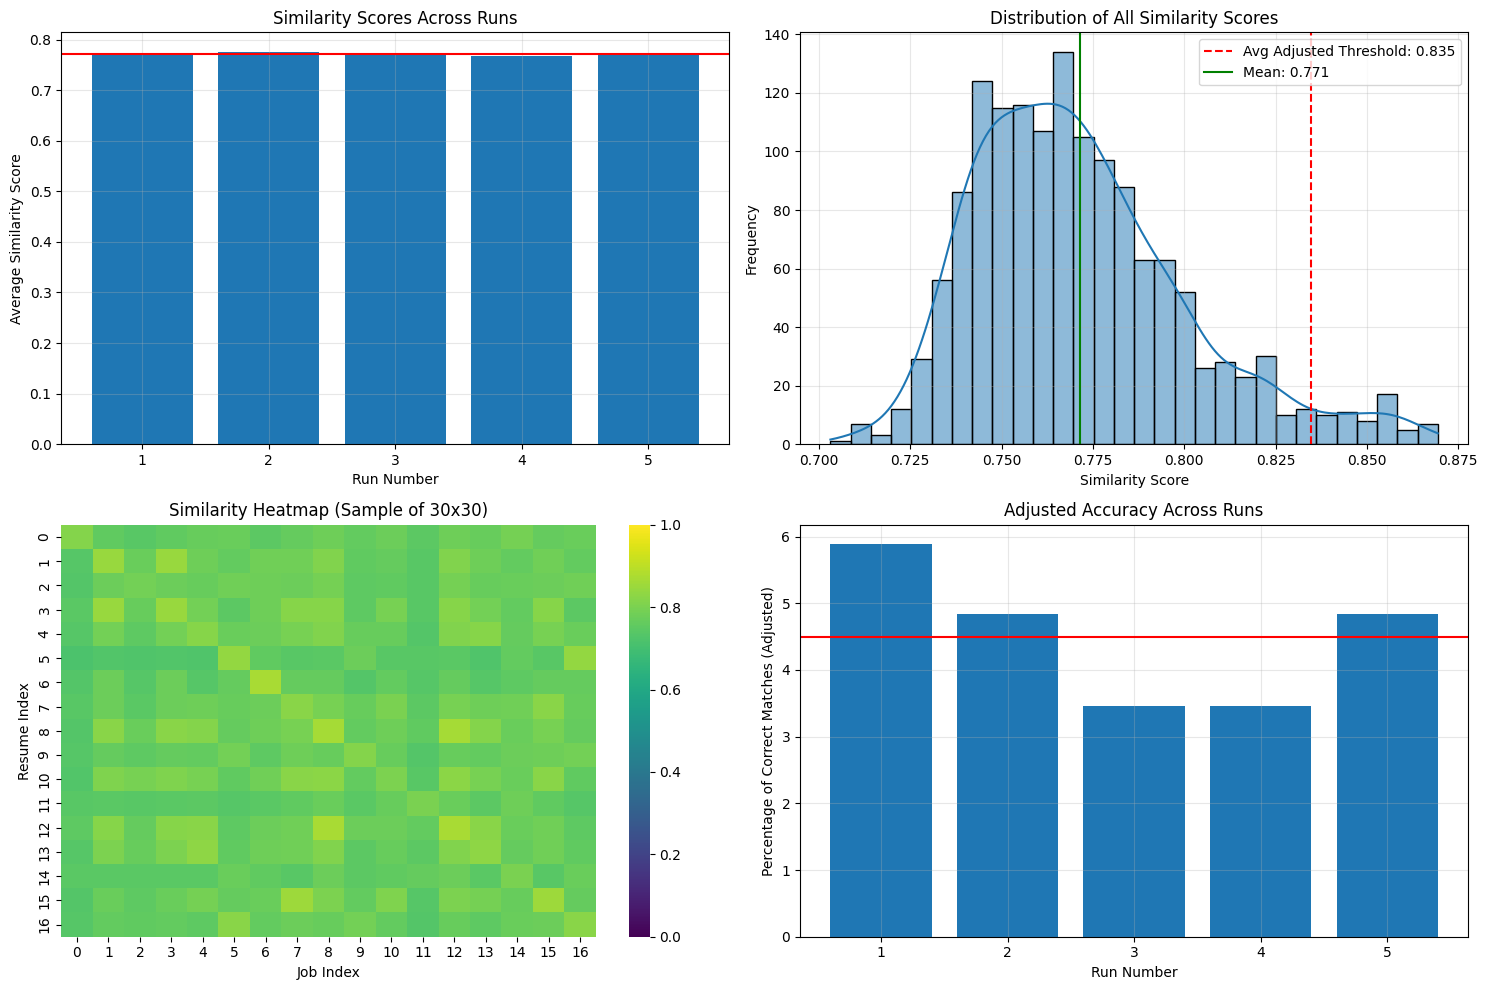


=== HIGH SIMILARITY MATCHES ===

Similarity Score: 0.869
Resume (processed): skill set experience implementing troubleshooting network security solution planning implementation knowledge multi vendor firewall cisco asa checkpoint upto r80 junipernetscreen fortinet fwsm familia...
Resume (before preprocessing): Skill Set â¢ Experience in Implementing, and troubleshooting network security solutions â¢ Planning and Implementation knowledge of multi vendor firewalls (Cisco ASA, Checkpoint (Upto R.80) Juniper/...
Job Category (annotated): Network Security Engineer
Predicted Job category: Network Security Engineer...
--------------------------------------------------------------------------------

Similarity Score: 0.869
Resume (processed): skill set experience implementing troubleshooting network security solution planning implementation knowledge multi vendor firewall cisco asa checkpoint upto r80 junipernetscreen fortinet fwsm familia...
Resume (before preprocessing): Skill Set â¢ Exp

In [46]:
num_runs = 5
similarity_threshold = 0.7

metrics_df, combined_df = run_multiple_evaluations(
    resume_df_final,
    jobs_df_final,
    num_runs=num_runs,
    similarity_threshold=similarity_threshold
)

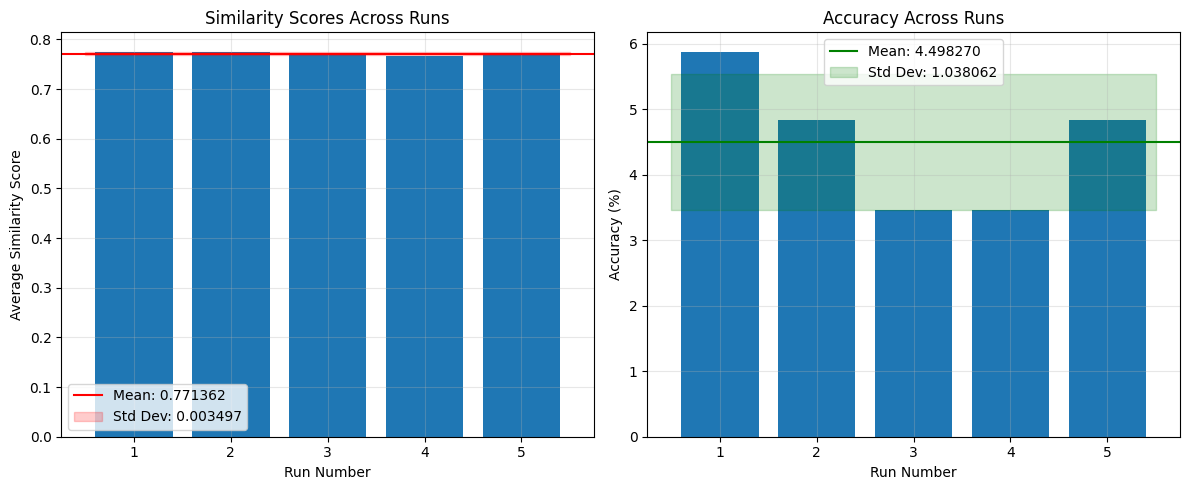

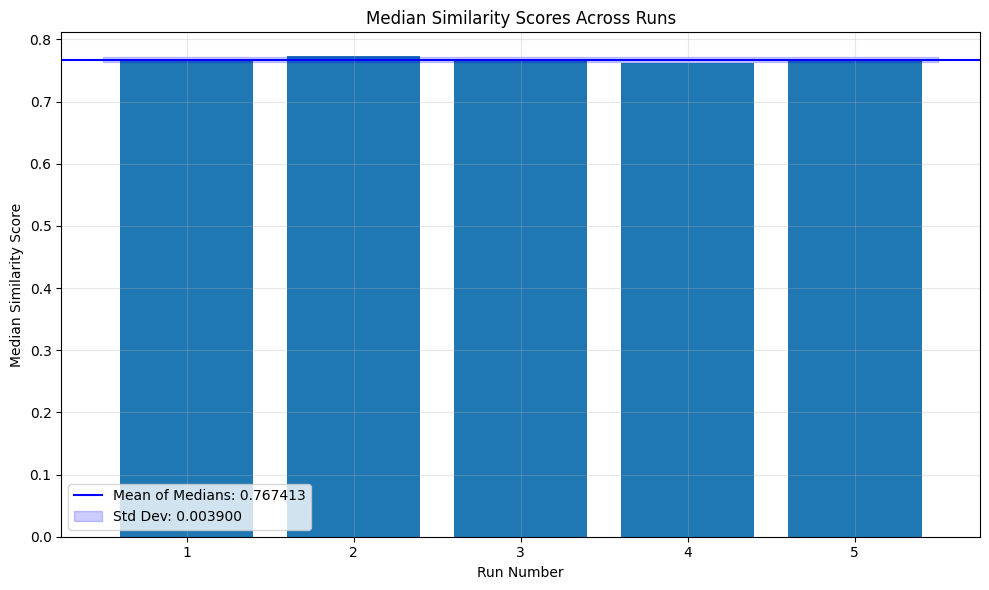

In [47]:
# Plot the similarity results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.bar(metrics_df['run'], metrics_df['avg_similarity'])
plt.axhline(y=metrics_df['avg_similarity'].mean(), color='r', linestyle='-',
            label=f'Mean: {metrics_df["avg_similarity"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['avg_similarity'].mean() - metrics_df['avg_similarity'].std()]*2,
    [metrics_df['avg_similarity'].mean() + metrics_df['avg_similarity'].std()]*2,
    color='r', alpha=0.2, label=f'Std Dev: {metrics_df["avg_similarity"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Average Similarity Score')
plt.title('Similarity Scores Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)

# Plot the accuracy results
plt.subplot(1, 2, 2)
plt.bar(metrics_df['run'], metrics_df['pct_correct_matches'])
plt.axhline(y=metrics_df['pct_correct_matches'].mean(), color='g', linestyle='-',
            label=f'Mean: {metrics_df["pct_correct_matches"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['pct_correct_matches'].mean() - metrics_df['pct_correct_matches'].std()]*2,
    [metrics_df['pct_correct_matches'].mean() + metrics_df['pct_correct_matches'].std()]*2,
    color='g', alpha=0.2, label=f'Std Dev: {metrics_df["pct_correct_matches"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Add a new plot for median similarity scores
plt.figure(figsize=(10, 6))
plt.bar(metrics_df['run'], metrics_df['median_similarity'])
plt.axhline(y=metrics_df['median_similarity'].mean(), color='b', linestyle='-',
            label=f'Mean of Medians: {metrics_df["median_similarity"].mean():.6f}')
plt.fill_between(
    [0.5, len(metrics_df)+0.5],
    [metrics_df['median_similarity'].mean() - metrics_df['median_similarity'].std()]*2,
    [metrics_df['median_similarity'].mean() + metrics_df['median_similarity'].std()]*2,
    color='b', alpha=0.2, label=f'Std Dev: {metrics_df["median_similarity"].std():.6f}'
)
plt.xlabel('Run Number')
plt.ylabel('Median Similarity Score')
plt.title('Median Similarity Scores Across Runs')
plt.xticks(metrics_df['run'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

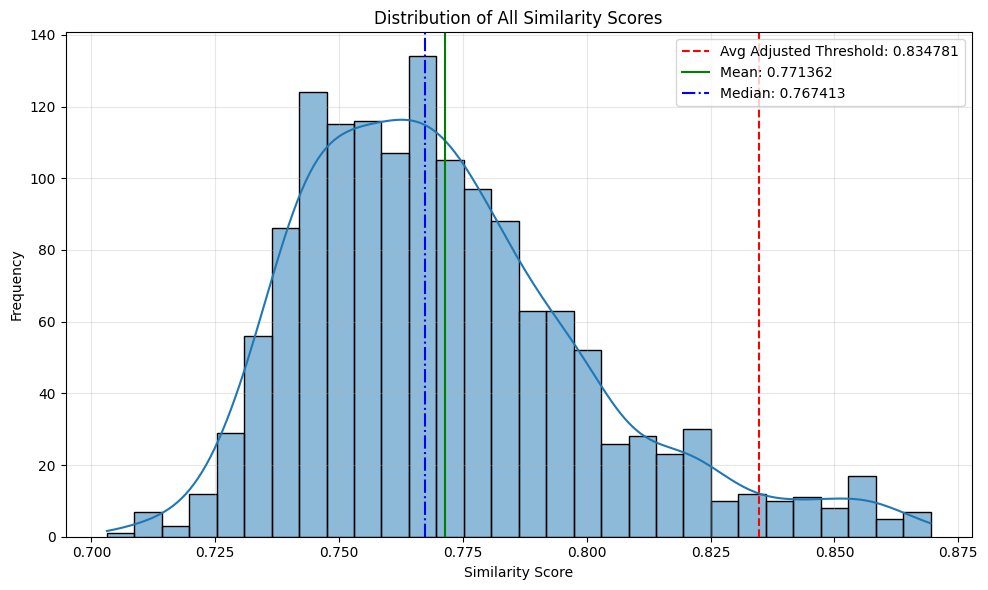

In [49]:
plt.figure(figsize=(10, 6))
sns.histplot(combined_df['similarity_score'], bins=30, kde=True)

# Show dynamic adjusted threshold (mean across runs)
plt.axvline(
    x=metrics_df['adjusted_threshold'].mean(),
    color='r',
    linestyle='--',
    label=f'Avg Adjusted Threshold: {metrics_df["adjusted_threshold"].mean():.6f}'
)

# Show mean similarity
plt.axvline(
    x=metrics_df['avg_similarity'].mean(),
    color='g',
    linestyle='-',
    label=f'Mean: {metrics_df["avg_similarity"].mean():.6f}'
)

# Show median similarity
plt.axvline(
    x=metrics_df['median_similarity'].mean(),
    color='b',
    linestyle='-.',
    label=f'Median: {metrics_df["median_similarity"].mean():.6f}'
)

plt.xlabel('Similarity Score')
plt.ylabel('Frequency')
plt.title('Distribution of All Similarity Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/tmp/ipython-input-2035955239.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(boxplot_data, labels=metrics_df['run'])


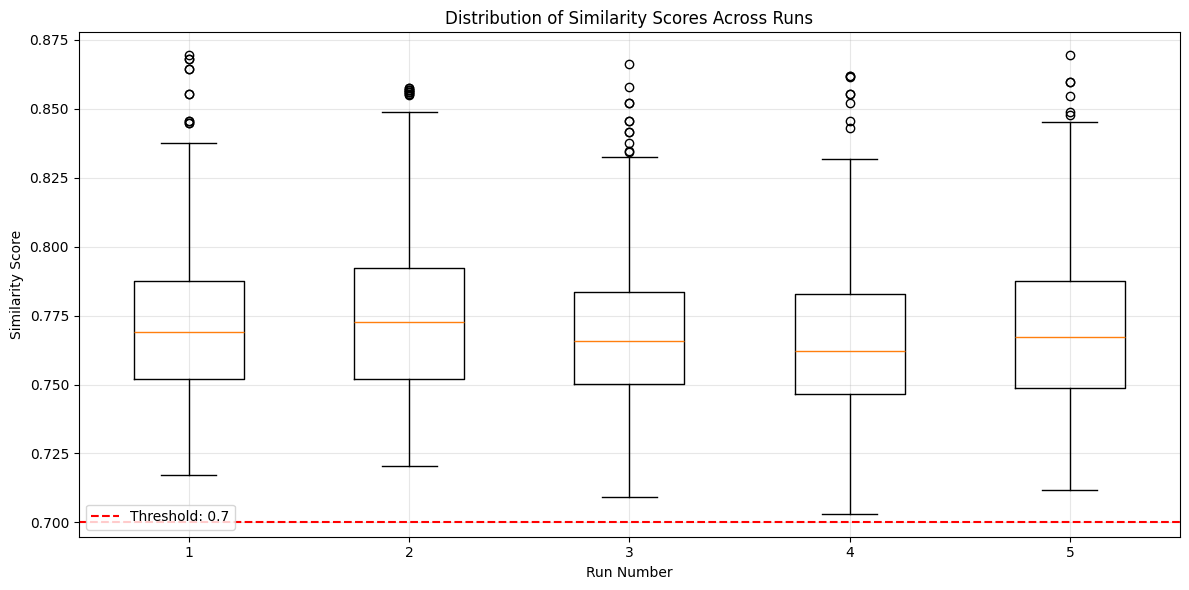

In [50]:
# 3. Box plot of similarity scores across runs
plt.figure(figsize=(12, 6))
boxplot_data = [combined_df[combined_df['run'] == run]['similarity_score'] for run in metrics_df['run']]
plt.boxplot(boxplot_data, labels=metrics_df['run'])
plt.axhline(y=similarity_threshold, color='r', linestyle='--', label=f'Threshold: {similarity_threshold}')
plt.xlabel('Run Number')
plt.ylabel('Similarity Score')
plt.title('Distribution of Similarity Scores Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


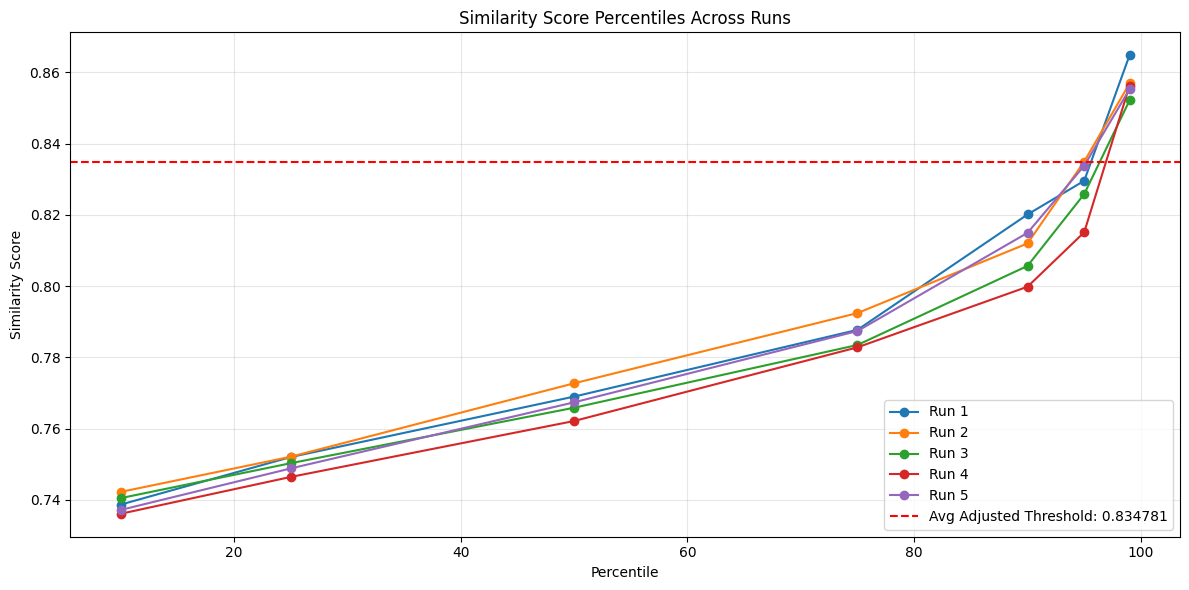

In [52]:
# 4. Percentile analysis
percentiles = [10, 25, 50, 75, 90, 95, 99]
plt.figure(figsize=(12, 6))

# Plot percentiles for each run
for run in metrics_df['run']:
    run_data = combined_df[combined_df['run'] == run]['similarity_score']
    percentile_values = np.percentile(run_data, percentiles)
    plt.plot(percentiles, percentile_values, marker='o', label=f'Run {run}')

# Plot average adjusted threshold across runs
plt.axhline(
    y=metrics_df['adjusted_threshold'].mean(),
    color='r',
    linestyle='--',
    label=f'Avg Adjusted Threshold: {metrics_df["adjusted_threshold"].mean():.6f}'
)

plt.xlabel('Percentile')
plt.ylabel('Similarity Score')
plt.title('Similarity Score Percentiles Across Runs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [53]:
# Extract wrong predictions (true vs predicted category mismatch)
wrong_preds = combined_df[combined_df['category_original'] != combined_df['predicted_job_category']]

print("\n=== SIMILARITY SCORES OF WRONG PREDICTIONS ===")
print(wrong_preds['similarity_score'].describe())

# Print only the lowest and highest wrong prediction scores
if not wrong_preds.empty:
    lowest_score = wrong_preds['similarity_score'].min()
    highest_score = wrong_preds['similarity_score'].max()

    print(f"\nLowest wrong prediction score across all runs: {lowest_score:.3f}")
    print(f"Highest wrong prediction score accross all runs: {highest_score:.3f}") # not the the average of per-run adjusted highest wrong prediction score
else:
    print("\nNo wrong predictions found based on category mismatch.")


=== SIMILARITY SCORES OF WRONG PREDICTIONS ===
count    1322.000000
mean        0.766021
std         0.023432
min         0.703126
25%         0.748287
50%         0.764503
75%         0.780945
max         0.847923
Name: similarity_score, dtype: float64

Lowest wrong prediction score: 0.703
Highest wrong prediction score: 0.848


In [54]:
median_score = wrong_preds['similarity_score'].median()
print(f"Median wrong prediction score: {median_score:.3f}")

Median wrong prediction score: 0.765


In [55]:
mean_between = (lowest_score + highest_score) / 2
print(f"Mean between lowest and highest: {mean_between:.3f}")

Mean between lowest and highest: 0.776


In [40]:
'''# Set threshold to the highest wrong similarity score
#adjusted_threshold = wrong_preds['similarity_score'].max()
# Set threshold to highest wrong score
adjusted_threshold = 0.698

# Recompute correct/wrong matches based on adjusted threshold
combined_df['is_correct_adjusted'] = combined_df['similarity_score'] >= adjusted_threshold

# Count correct and wrong matches
num_correct = combined_df['is_correct_adjusted'].sum()
num_wrong = len(combined_df) - num_correct
accuracy_adjusted = num_correct / len(combined_df) * 100

# Summary table
plt.figure(figsize=(12, 6))
plt.axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Adjusted Threshold', f"{adjusted_threshold:.3f}"],
    ['Correct Matches', f"{num_correct}"],
    ['Wrong Matches', f"{num_wrong}"],
    ['Total Matches', f"{len(combined_df)}"],
    ['Adjusted Accuracy (%)', f"{accuracy_adjusted:.2f}%"]
]

table = plt.table(cellText=table_data, cellLoc='center', loc='center', colWidths=[0.4, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
plt.title('Summary Statistics Using Highest Wrong Score as Threshold', fontsize=16, pad=20)
plt.tight_layout()
plt.show()'''

SyntaxError: incomplete input (ipython-input-3752804174.py, line 32)

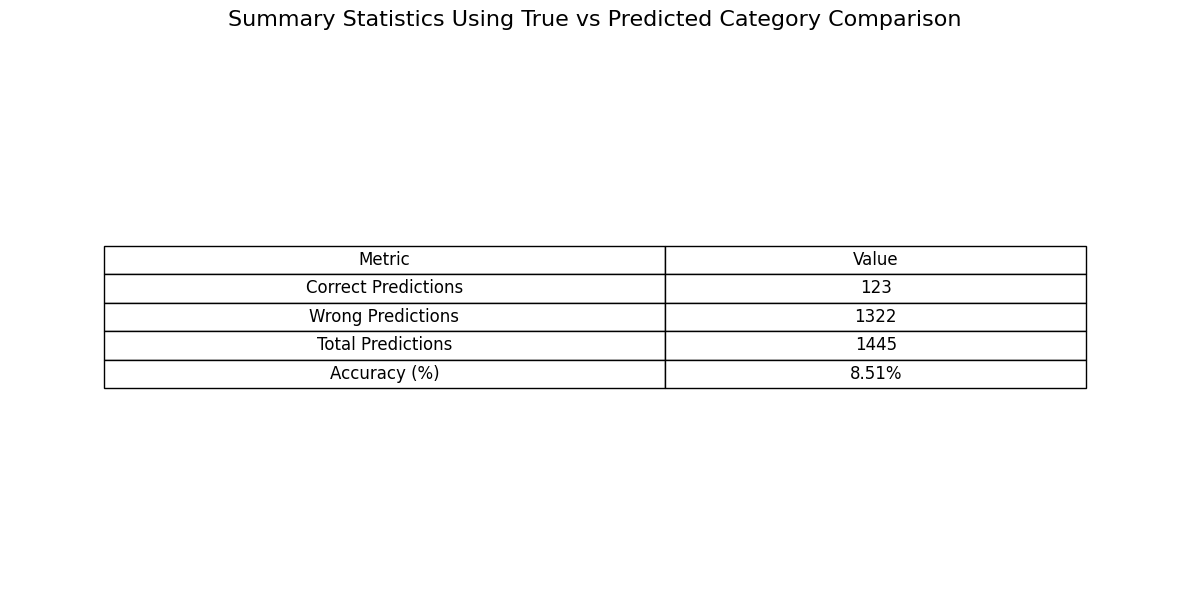

In [56]:
# Define correctness based on category match
combined_df['is_correct_category'] = combined_df['category_original'] == combined_df['predicted_job_category']

# Count correct and wrong predictions
num_correct_category = combined_df['is_correct_category'].sum()
num_wrong_category = len(combined_df) - num_correct_category
accuracy_category = num_correct_category / len(combined_df) * 100

# Summary table
plt.figure(figsize=(12, 6))
plt.axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Correct Predictions', f"{num_correct_category}"],
    ['Wrong Predictions', f"{num_wrong_category}"],
    ['Total Predictions', f"{len(combined_df)}"],
    ['Accuracy (%)', f"{accuracy_category:.2f}%"]
]

table = plt.table(cellText=table_data, cellLoc='center', loc='center', colWidths=[0.4, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.5)
plt.title('Summary Statistics Using True vs Predicted Category Comparison', fontsize=16, pad=20)
plt.tight_layout()
plt.show()